# Group J - Problem Set 2

## Queueing Theory Simulations

In [20]:
# Imports
import matplotlib.pyplot as plt
import numpy as np
import random
import math
import pandas as pd

## a) Arrival and Service Rate Estimates

In [21]:
# data


arrival_nums = np.array([12, 12, 13, 11, 14, 12, 13, 15, 11, 13]) * 1/5
service_nums = np.array([15, 10, 17, 14, 13, 16, 12, 15, 14, 14]) * 1/5

arrival_rate_est = sum(arrival_nums)/len(arrival_nums)
service_rate_est = sum(service_nums)/len(service_nums)

print(f"Average Arrival Rate (per minute): {round(arrival_rate_est, 3)}")
print(f"Average Service Rate (per minute): {round(service_rate_est, 3)}")

Average Arrival Rate (per minute): 2.52
Average Service Rate (per minute): 2.8


## a) Visualisations for Part A

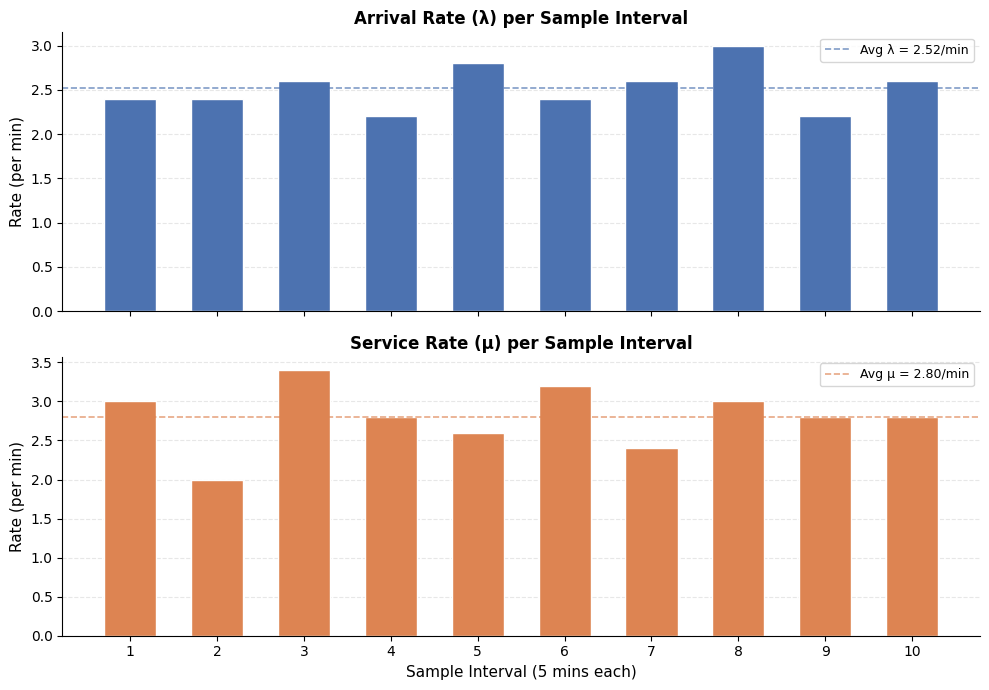

In [22]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 7), sharex=True)

x = np.arange(1, len(arrival_nums) + 1)

# Arrival rates
ax1.bar(x, arrival_nums, color='#4C72B0', edgecolor='white', width=0.6)
ax1.axhline(y=arrival_rate_est, color='#4C72B0', linestyle='--', linewidth=1.2, alpha=0.7,
            label=f'Avg λ = {arrival_rate_est:.2f}/min')
ax1.set_ylabel('Rate (per min)', fontsize=11)
ax1.set_title('Arrival Rate (λ) per Sample Interval', fontsize=12, fontweight='bold')
ax1.legend(fontsize=9)
ax1.set_axisbelow(True)
ax1.yaxis.grid(True, linestyle='--', alpha=0.3)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# Service rates
ax2.bar(x, service_nums, color='#DD8452', edgecolor='white', width=0.6)
ax2.axhline(y=service_rate_est, color='#DD8452', linestyle='--', linewidth=1.2, alpha=0.7,
            label=f'Avg μ = {service_rate_est:.2f}/min')
ax2.set_xlabel('Sample Interval (5 mins each)', fontsize=11)
ax2.set_ylabel('Rate (per min)', fontsize=11)
ax2.set_title('Service Rate (μ) per Sample Interval', fontsize=12, fontweight='bold')
ax2.set_xticks(x)
ax2.legend(fontsize=9)
ax2.set_axisbelow(True)
ax2.yaxis.grid(True, linestyle='--', alpha=0.3)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()


## b) M/M/1 Queue Simulation

In [23]:
# inverse-transform sampling for random numbers:
def exponential_sample(lamda):
    r = random.random()
    return -math.log(r) / lamda

def generate_samples(d):
    samples_interarrival = [exponential_sample(arrival_rate_est) for _ in range(d)]
    samples_service = [exponential_sample(service_rate_est) for _ in range(d)]
    return samples_interarrival, samples_service

In [24]:
# set up recursion function using Lindley's equation
def recurse_lindley(service_times, interarrival_times, d):
    
    waiting_times = [0]*d
    for i in range(d-1):
        waiting_times[i+1] = max(0, waiting_times[i] + service_times[i] - interarrival_times[i])
    time_in_system = [waiting_times[i] + service_times[i] for i in range(d)]

    avg_wait_queue = sum(waiting_times) / d
    avg_system_time = sum(time_in_system) / d
    return waiting_times

In [25]:
# record events (when customers enter or leave)
def record_events(service_times, interarrival_times, waiting_times, d):

    # generate events tracker
    arrival_times = [0]*d
    for i in range(1,d):
        arrival_times[i] = arrival_times[i-1] + interarrival_times[i-1]
    service_start_times = [arrival_times[i] + waiting_times[i] for i in range(d)]
    service_end_times = [service_start_times[i] + service_times[i] for i in range(d)]
    events = []
    for time in arrival_times:
        events.append((time, +1))
    for time in service_end_times:
        events.append((time, -1))
    events.sort()

    return events

# report required estimates from simulation run
def report_estimates(waiting_times, events, d):

    # i) estimate average queue length + iii) utilisation ratio
    time_server_occupied = 0
    previous_time = 0
    time_weighted_total_L = 0
    current_L = 0
    for time, change_L in events:
        time_delta = time - previous_time
        if current_L > 0:
            time_server_occupied += time_delta
        time_weighted_total_L += current_L * time_delta
        previous_time = time
        current_L += change_L
    average_L = time_weighted_total_L / previous_time
    utilisation_ratio = time_server_occupied / previous_time
    
    # ii) estimate average wait time
    average_wait = sum(waiting_times) / d

    return np.array([average_L, average_wait, utilisation_ratio])
    

In [26]:
# calculate theoretical values:
rho = arrival_rate_est / service_rate_est
expected_L = rho / (1 - rho)
expected_wait = rho / (service_rate_est - arrival_rate_est)

In [27]:
n = 100
d = 100000

estimates_list = []

for run in range(n):
    random.seed(run)
    samples_interarrival, samples_service = generate_samples(d)
    waiting_times = recurse_lindley(samples_service, samples_interarrival, d)
    events = record_events(samples_service, samples_interarrival, waiting_times, d)
    estimates = report_estimates(waiting_times, events, d)
    estimates_list.append(estimates)

estimates_array = np.array(estimates_list)
means = estimates_array.mean(axis=0)
stds = estimates_array.std(axis=0, ddof=1)
ci95 = 1.96 * stds / np.sqrt(n)

estimate_L, estimate_wait, estimate_utilisation_ratio = means
ci_L, ci_wait, ci_util = ci95
rho = arrival_rate_est / service_rate_est
expected_L = rho / (1 - rho)
expected_wait = rho / (service_rate_est - arrival_rate_est)

data = {
    "Metric": ["Queue Length (L)", "Waiting Time (mins)", "Utilisation Ratio"],
    "Theoretical": [expected_L, expected_wait, rho],
    "Monte Carlo Estimate": means,
    "95% CI (±)": ci95,
    "% Error": np.abs(means - [expected_L, expected_wait, rho]) / [expected_L, expected_wait, rho] * 100,
    "Coverage": [
        "Yes" if abs(means[0] - expected_L) <= ci_L else "No",
        "Yes" if abs(means[1] - expected_wait) <= ci_wait else "No",
        "Yes" if abs(means[2] - rho) <= ci_util else "No"
    ]
}

df = pd.DataFrame(data)
df[["Theoretical", "Monte Carlo Estimate"]] = df[["Theoretical", "Monte Carlo Estimate"]].round(4)
df["95% CI (±)"] = df["95% CI (±)"].round(4)
df["% Error"] = df["% Error"].round(3)

print("=== M/M/1 Queue: Theoretical vs Monte Carlo Estimates ===\n")
print(df.to_string(index=False))

=== M/M/1 Queue: Theoretical vs Monte Carlo Estimates ===

             Metric  Theoretical  Monte Carlo Estimate  95% CI (±)  % Error Coverage
   Queue Length (L)       9.0000                8.9193      0.1077    0.897      Yes
Waiting Time (mins)       3.2143                3.1844      0.0417    0.930      Yes
  Utilisation Ratio       0.9000                0.8990      0.0008    0.110       No


## b) Visualisations for M/M/1 Queue Simulation

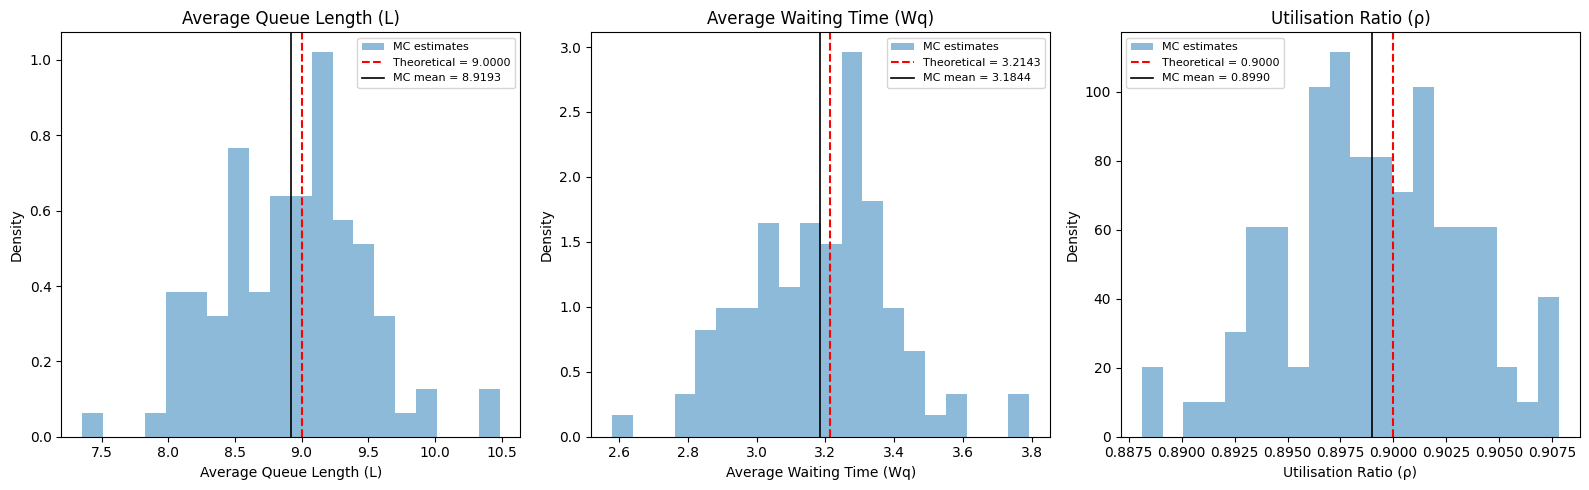

In [34]:
# Distribution of estimates across 100 Monte Carlo runs
plt.figure(figsize=(16, 5))

titles = ["Average Queue Length (L)", "Average Waiting Time (Wq)", "Utilisation Ratio (ρ)"]
theoretical = [expected_L, expected_wait, rho]

for i in range(3):
    plt.subplot(1, 3, i+1)
    plt.hist(estimates_array[:, i], bins=20, density=True, alpha=0.5, label="MC estimates")
    plt.axvline(theoretical[i], color='r', linestyle='--', linewidth=1.5,
                label=f"Theoretical = {theoretical[i]:.4f}")
    plt.axvline(means[i], color='black', linestyle='-', linewidth=1.2,
                label=f"MC mean = {means[i]:.4f}")
    plt.xlabel(titles[i])
    plt.ylabel("Density")
    plt.title(titles[i])
    plt.legend(fontsize=8)

plt.tight_layout()
plt.show()

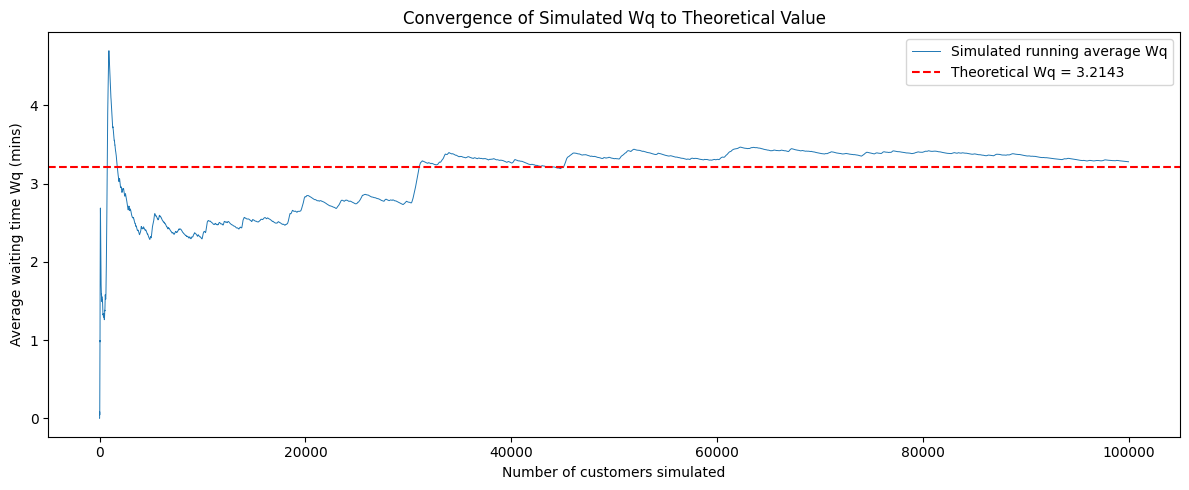

In [44]:
# Convergence of running average waiting time
random.seed(38)
samples_interarrival, samples_service = generate_samples(d)
waiting_times_conv = recurse_lindley(samples_service, samples_interarrival, d)

running_avg = np.cumsum(waiting_times_conv) / np.arange(1, d + 1)

plt.figure(figsize=(12, 5))
plt.plot(range(1, d + 1), running_avg, linewidth=0.7, label="Simulated running average Wq")
plt.axhline(y=expected_wait, color='r', linestyle='--', linewidth=1.5,
            label=f"Theoretical Wq = {expected_wait:.4f}")
plt.xlabel("Number of customers simulated")
plt.ylabel("Average waiting time Wq (mins)")
plt.title("Convergence of Simulated Wq to Theoretical Value")
plt.legend()
plt.tight_layout()
plt.show()

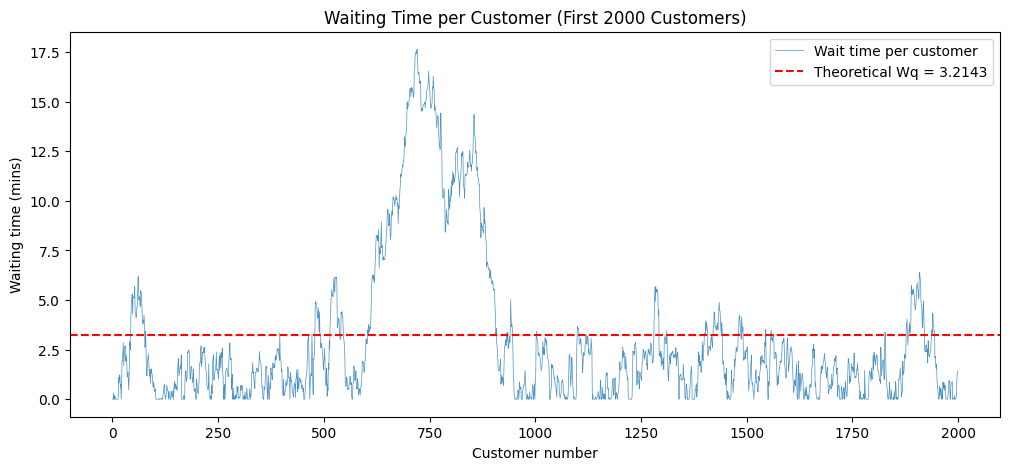

In [42]:
# Waiting time per customer (first 2000 from previous run)
plt.figure(figsize=(12, 5))
plt.plot(range(2000), waiting_times_conv[:2000], linewidth=0.5, alpha=0.8, label="Wait time per customer")
plt.axhline(y=expected_wait, color='r', linestyle='--', linewidth=1.5,
            label=f"Theoretical Wq = {expected_wait:.4f}")
plt.xlabel("Customer number")
plt.ylabel("Waiting time (mins)")
plt.title("Waiting Time per Customer (First 2000 Customers)")
plt.legend()
plt.show()